In [1]:
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"
os.environ["SPARK_HOME"] = "/Users/kinchintong/project/tumult-labs/spark-4.0.1-bin-hadoop3"

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import findspark
findspark.init(os.environ["SPARK_HOME"])
from math import floor
from pyspark import SparkFiles
from pyspark.sql import SparkSession, types as T, functions as F
from tmlt.analytics.privacy_budget import PureDPBudget
from tmlt.analytics.protected_change import AddOneRow
from tmlt.analytics.query_builder import QueryBuilder
from tmlt.analytics.session import Session, ColumnType
from tmlt.analytics.keyset import KeySet
from functools import reduce
from tmlt.analytics import (
    AddOneRow,
    PureDPBudget,
    QueryBuilder,
    Session,
    AddRowsWithID,
)

from tmlt.analytics.truncation_strategy import TruncationStrategy

# Silence some Spark warnings
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', ResourceWarning)

findspark.init()

# Set up Spark
spark = (
    SparkSession.builder
    .appName("tpch-setup")
    .master("local[*]")           # drop if connecting to a cluster
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.driver.memory", "16g")
    .config("spark.executor.memory", "16g")
    .config("spark.driver.maxResultSize", "2g")
    .getOrCreate()
)
print("Spark version:", spark.version)

spark.sparkContext.setLogLevel("ERROR")

spark.conf.set("spark.sql.session.timeZone", "UTC")

# CREATE EMPTY TABLES (schema only) ----
def create_empty_tables():
    for t in TABLES:
        empty = spark.createDataFrame([], SCHEMAS[t])
        # managed Parquet tables; change to .format("delta") if using Delta
        #empty.write.mode("overwrite").format("parquet").saveAsTable(t)
    print(f"Created empty schema in database `{DB}`.")

# LOAD FROM CSV / .tbl (pipe-delimited with trailing '|') ----
def load_from_csv(src_dir: str):
    for t in TABLES:
        schema = SCHEMAS[t]
        path = f"{src_dir}/{t}.tbl"   # change to .csv if needed
        #only if the path exists
        if not os.path.exists(path):
            print(f"Path does not exist: {path}")
            continue
        
        print(f"Loading {t} from {path}...")

        # create a temporary wide schema of string columns (named) to absorb trailing '|'
        n_cols = len(schema.fields) + 1
        tmp_fields = [T.StructField(f"_c{i}", T.StringType(), True) for i in range(n_cols)]
        tmp_schema = T.StructType(tmp_fields)
        #print("tmp_schema:", tmp_schema)
        df_raw = (spark.read
                  .option("sep", "|")
                  .option("header", "false")
                  .option("mode", "PERMISSIVE")
                  .schema(tmp_schema)  # read wide to absorb trailing '|'
                  .csv(path))
        #print(f"Raw schema for {t}:")
        #df_raw.printSchema()
        
        # keep only first N columns and cast to target schema
        cols = df_raw.columns[:len(schema.fields)]
        df = df_raw.select([F.col(c).alias(schema.fields[i].name) for i, c in enumerate(cols)])
        # cast columns to target types
        for f in schema.fields:
            if isinstance(f.dataType, T.DateType):
                df = df.withColumn(f.name, F.to_date(F.col(f.name), "yyyy-MM-dd"))
            elif isinstance(f.dataType, T.DecimalType):
                df = df.withColumn(f.name, F.col(f.name).cast(f.dataType))
            elif isinstance(f.dataType, T.IntegerType):
                df = df.withColumn(f.name, F.col(f.name).cast("int"))
            # strings need no cast
        df.write.mode("overwrite").format("parquet").saveAsTable(t)
        print(f"Loaded {t} from {path}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/17 08:25:29 WARN Utils: Your hostname, kinchins-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.4.184 instead (on interface en0)
25/12/17 08:25:29 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/17 08:25:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.0.1


In [2]:
DB = "tpch"                          # change as you like

# Define canonical TPC-H schemas ----
dec = lambda p, s: T.DecimalType(p, s)
SCHEMAS = {
    "region":   T.StructType([
        T.StructField("r_regionkey", T.IntegerType(), False),
        T.StructField("r_name",      T.StringType(),  False),
        T.StructField("r_comment",   T.StringType(),  True),
    ]),
    "nation":   T.StructType([
        T.StructField("n_nationkey", T.IntegerType(), False),
        T.StructField("n_name",      T.StringType(),  False),
        T.StructField("n_regionkey", T.IntegerType(), False),
        T.StructField("n_comment",   T.StringType(),  True),
    ]),
    "part":     T.StructType([
        T.StructField("p_partkey",     T.IntegerType(), False),
        T.StructField("p_name",        T.StringType(),  False),
        T.StructField("p_mfgr",        T.StringType(),  False),
        T.StructField("p_brand",       T.StringType(),  False),
        T.StructField("p_type",        T.StringType(),  False),
        T.StructField("p_size",        T.IntegerType(), False),
        T.StructField("p_container",   T.StringType(),  False),
        T.StructField("p_retailprice", T.FloatType(),   False),
        T.StructField("p_comment",     T.StringType(),  True),
    ]),
    "supplier": T.StructType([
        T.StructField("s_suppkey",   T.IntegerType(), False),
        T.StructField("s_name",      T.StringType(),  False),
        T.StructField("s_address",   T.StringType(),  False),
        T.StructField("s_nationkey", T.IntegerType(), False),
        T.StructField("s_phone",     T.StringType(),  False),
        T.StructField("s_acctbal",   T.FloatType(),   False),
        T.StructField("s_comment",   T.StringType(),  True),
    ]),
    "partsupp": T.StructType([
        T.StructField("ps_partkey",    T.IntegerType(), False),
        T.StructField("ps_suppkey",    T.IntegerType(), False),
        T.StructField("ps_availqty",   T.IntegerType(), False),
        T.StructField("ps_supplycost", T.FloatType(),   False),
        T.StructField("ps_comment",    T.StringType(),  True),
    ]),
    "customer": T.StructType([
        T.StructField("c_custkey",   T.IntegerType(), False),
        T.StructField("c_name",      T.StringType(),  False),
        T.StructField("c_address",   T.StringType(),  False),
        T.StructField("c_nationkey", T.IntegerType(), False),
        T.StructField("c_phone",     T.StringType(),  False),
        T.StructField("c_acctbal",   T.FloatType(),   False),
        T.StructField("c_mktsegment",T.StringType(),  True),
        T.StructField("c_comment",   T.StringType(),  True),
    ]),
    "orders":   T.StructType([
        T.StructField("o_orderkey",     T.IntegerType(), False),
        T.StructField("o_custkey",      T.IntegerType(), False),
        T.StructField("o_orderstatus",  T.StringType(),  False),
        T.StructField("o_totalprice",   T.FloatType(),   False),
        T.StructField("o_orderdate",    T.DateType(),    False),
        T.StructField("o_orderpriority",T.StringType(),  False),
        T.StructField("o_clerk",        T.StringType(),  False),
        T.StructField("o_shippriority", T.IntegerType(), False),
        T.StructField("o_comment",      T.StringType(),  True),
    ]),
    "lineitem": T.StructType([
        T.StructField("l_orderkey",      T.IntegerType(), False),
        T.StructField("l_partkey",       T.IntegerType(), False),
        T.StructField("l_suppkey",       T.IntegerType(), False),
        T.StructField("l_linenumber",    T.IntegerType(), False),
        T.StructField("l_quantity",      T.FloatType(),   False),
        T.StructField("l_extendedprice", T.FloatType(),   False),
        T.StructField("l_discount",      T.FloatType(),   False),
        T.StructField("l_tax",           T.FloatType(),   False),
        T.StructField("l_returnflag",    T.StringType(),  False),
        T.StructField("l_linestatus",    T.StringType(),  False),
        T.StructField("l_shipdate",      T.DateType(),    False),
        T.StructField("l_commitdate",    T.DateType(),    False),
        T.StructField("l_receiptdate",   T.DateType(),    False),
        T.StructField("l_shipinstruct",  T.StringType(),  False),
        T.StructField("l_shipmode",      T.StringType(),  False),
        T.StructField("l_comment",       T.StringType(),  True),
    ]),
}
TABLES = ["region","nation","part","supplier","partsupp","customer","orders","lineitem"]
spark.sql(f"CREATE DATABASE IF NOT EXISTS {DB}")
spark.catalog.setCurrentDatabase(DB)

create_empty_tables()


Created empty schema in database `tpch`.


In [3]:
SRC_CSV_DIR = "./raw"    # where *.tbl live
load_from_csv(SRC_CSV_DIR)

# Quick smoke test:
spark.sql("SHOW TABLES").show(truncate=False)
# show record count for each table
for t in TABLES:
    print(f"Table {t} has {spark.sql(f'SELECT count(*) FROM {t}').collect()[0][0]} records.")

Loading region from ./raw/region.tbl...
Loaded region from ./raw/region.tbl
Loading nation from ./raw/nation.tbl...
Loaded nation from ./raw/nation.tbl
Loading part from ./raw/part.tbl...
Loaded part from ./raw/part.tbl
Loading supplier from ./raw/supplier.tbl...
Loaded supplier from ./raw/supplier.tbl
Loading partsupp from ./raw/partsupp.tbl...


Loaded partsupp from ./raw/partsupp.tbl
Loading customer from ./raw/customer.tbl...
Loaded customer from ./raw/customer.tbl
Loading orders from ./raw/orders.tbl...


Loaded orders from ./raw/orders.tbl
Loading lineitem from ./raw/lineitem.tbl...


Loaded lineitem from ./raw/lineitem.tbl
+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
|tpch     |customer |false      |
|tpch     |lineitem |false      |
|tpch     |nation   |false      |
|tpch     |orders   |false      |
|tpch     |part     |false      |
|tpch     |partsupp |false      |
|tpch     |region   |false      |
|tpch     |supplier |false      |
+---------+---------+-----------+

Table region has 5 records.
Table nation has 25 records.
Table part has 200000 records.
Table supplier has 10000 records.
Table partsupp has 800000 records.
Table customer has 150000 records.
Table orders has 1500000 records.
Table lineitem has 6001215 records.


## PrivateSQL paper evaluation
### Dataset: TPC-H
### Privacy Policy: Customer
### Privacy Budget ϵ: 1.0

privacy model:
customer table is private
orders table have foeign key of customer table (custkey)
lineitem table have forign key of orders table (orderkey)

***
## TPC-H Queries Evaluated

- **Q1 - Pricing Summary Report Query**<br>
    This query reports the amount of business that was billed, shipped, and returned.

- **Q4 - Order Priority Checking Query**<br>
    This query determines how well the order priority system is working and gives an assessment of customer satisfac-
tion.

- **Q13 - Customer Distribution Query**<br>
    This query seeks relationships between customers and the size of their orders.

- **Q16 - Parts/Supplier Relationship Query**<br>
    This query finds out how many suppliers can supply parts with given attributes. It might be used, for example, to
determine whether there is a sufficient number of suppliers for heavily ordered parts.

In [4]:
SRC_CSV_DIR = "./raw"
dataframes = {}
tpch_query_results = {}

TABLES = ["region","nation","part","supplier","partsupp","customer","orders","lineitem"]
for table_name in TABLES:
    path = f"{SRC_CSV_DIR}/{table_name}.tbl"
    schema = SCHEMAS[table_name]
    dataframes[table_name] = (spark.read
                .option("sep", "|")
                .option("header", "false")
                .option("mode", "PERMISSIVE")
                .schema(schema)
                .csv(path))

#q1 view
q1_view = """
SELECT
    l_returnflag,
    l_linestatus,
    l_quantity,
    l_extendedprice,
    l_discount,
    l_tax,
    l_shipdate,
    CAST(l_extendedprice AS DOUBLE) * (1.0 - CAST(l_discount AS DOUBLE)) AS disc_price,
    CAST(l_extendedprice AS DOUBLE) * (1.0 - CAST(l_discount AS DOUBLE)) * (1.0 + CAST(l_tax AS DOUBLE)) AS charge
FROM lineitem;
"""

V_q1 = spark.sql(q1_view)
dataframes["V_q1"] = V_q1

q4_view = """
SELECT DISTINCT
  o.o_orderkey,
  o.o_orderpriority
FROM orders o
JOIN lineitem l
  ON l.l_orderkey = o.o_orderkey
WHERE l.l_commitdate < l.l_receiptdate;
"""
V_q4 = spark.sql(q4_view)
dataframes["V_q4"] = V_q4

WORD1 = 'special'
WORD2 = 'requests'
q13_view = f"""
SELECT
  c.c_custkey,
  COUNT(o.o_orderkey) AS c_count
FROM customer c
LEFT JOIN orders o
  ON  o.o_custkey = c.c_custkey
  AND o_comment NOT LIKE '%{WORD1}%{WORD2}%'
GROUP BY c.c_custkey;
"""

V_q13 = spark.sql(q13_view)
dataframes["V_q13"] = V_q13

q16_view = """
SELECT DISTINCT
  p.p_brand,
  p.p_type,
  p.p_size,
  ps.ps_suppkey
FROM part p
JOIN partsupp ps
  ON p.p_partkey = ps.ps_partkey
JOIN supplier s
  ON s.s_suppkey = ps.ps_suppkey
WHERE s.s_comment NOT LIKE '%Customer%Complaints%'
"""
V_q16 = spark.sql(q16_view)
dataframes["V_q16"] = V_q16

for table_name in dataframes:
    print(f"Schema for table: {table_name}")
    dataframes[table_name].show(5)


budget = PureDPBudget(float("inf"))
#budget = PureDPBudget(3)

id_space = "tpch_id_space"

session = (
    Session.Builder()
    .with_privacy_budget(budget)
    .with_id_space(id_space)
    .with_private_dataframe(
        "V_q1",
        dataframes["V_q1"],
        protected_change=AddOneRow(),
    )
    .with_private_dataframe(
        "V_q4",
        dataframes["V_q4"],
        protected_change=AddOneRow(),
    )
    .with_private_dataframe(
        "V_q13",
        dataframes["V_q13"],
        protected_change=AddOneRow(),
    )
    .with_private_dataframe(
        "V_q16",
        dataframes["V_q16"],
        protected_change=AddOneRow(),
    )
    .with_private_dataframe(
        "lineitem",
        dataframes["lineitem"],
        protected_change=AddOneRow(),
    )
    .with_private_dataframe(
        "orders",
        dataframes["orders"],
        protected_change=AddOneRow(),
    )
    .with_private_dataframe(
        "customer",
        dataframes["customer"],
        protected_change=AddOneRow(),
    )
    .with_public_dataframe(
        "region",
        dataframes["region"],
    )
    .with_public_dataframe(
        "nation",
        dataframes["nation"],
    )
    .with_public_dataframe(
        "part",
        dataframes["part"],
    )
    .with_public_dataframe(
        "supplier",
        dataframes["supplier"],
    )
    .with_public_dataframe(
        "partsupp",
        dataframes["partsupp"],
    )
    .build()
)

print(f"Private dataframes: {session.private_sources}")
print(f"Public dataframes: {session.public_sources}")
for source_id in session.private_sources:
    print(f"Schema for {source_id}:")
    x = session.get_schema(source_id)
    print(x)


Schema for table: region
+-----------+-----------+--------------------+
|r_regionkey|     r_name|           r_comment|
+-----------+-----------+--------------------+
|          0|     AFRICA|lar deposits. bli...|
|          1|    AMERICA|hs use ironic, ev...|
|          2|       ASIA|ges. thinly even ...|
|          3|     EUROPE|ly final courts c...|
|          4|MIDDLE EAST|uickly special ac...|
+-----------+-----------+--------------------+

Schema for table: nation
+-----------+---------+-----------+--------------------+
|n_nationkey|   n_name|n_regionkey|           n_comment|
+-----------+---------+-----------+--------------------+
|          0|  ALGERIA|          0| haggle. carefull...|
|          1|ARGENTINA|          1|al foxes promise ...|
|          2|   BRAZIL|          1|y alongside of th...|
|          3|   CANADA|          1|eas hang ironic, ...|
|          4|    EGYPT|          4|y above the caref...|
+-----------+---------+-----------+--------------------+
only showing 

+----------+---------------+
|o_orderkey|o_orderpriority|
+----------+---------------+
|        34|       3-MEDIUM|
|        65|       1-URGENT|
|       101|       3-MEDIUM|
|       133|       1-URGENT|
|       193|       1-URGENT|
+----------+---------------+
only showing top 5 rows
Schema for table: V_q13
+---------+-------+
|c_custkey|c_count|
+---------+-------+
|      148|     21|
|      463|     18|
|      471|      0|
|      496|     21|
|      833|     13|
+---------+-------+
only showing top 5 rows
Schema for table: V_q16
+--------+--------------------+------+----------+
| p_brand|              p_type|p_size|ps_suppkey|
+--------+--------------------+------+----------+
|Brand#12|LARGE POLISHED NI...|    48|        21|
|Brand#13| LARGE BRUSHED STEEL|     8|      5035|
|Brand#14|ECONOMY POLISHED ...|    24|        79|
|Brand#32|PROMO ANODIZED STEEL|     1|      5125|
|Brand#34|MEDIUM ANODIZED B...|    25|       234|
+--------+--------------------+------+----------+
only showing 

In [18]:
def query_dp_eval(eps: PureDPBudget, session: Session, query_num, query_dp_run, num_runs: int = 1, start_run: int = 0):
  for run in range(start_run,num_runs):
    print(f"Running Q{query_num} DP run {run+1}/{num_runs} with epsilon={eps.epsilon}...")
    runx = query_dp_run(eps, session)

    output_file = f"./output/dp_no_truncation/q{query_num}/q{query_num}_dp_result_eps_{eps.epsilon}_runs_{run+1}_csv"

    runx.coalesce(1).write \
      .mode("overwrite") \
      .option("header", "true") \
      .csv(output_file)

In [6]:
tpch_query_results = {}

***
### Q1 — Pricing Summary Report

```SQL
SELECT
    l_returnflag,
    l_linestatus,
    SUM(l_quantity) AS sum_qty,
    SUM(l_extendedprice) AS sum_base_price,
    SUM(l_extendedprice * (1 - l_discount)) AS sum_disc_price,
    SUM(l_extendedprice * (1 - l_discount) * (1 + l_tax)) AS sum_charge,
    AVG(l_quantity) AS avg_qty,
    AVG(l_extendedprice) AS avg_price,
    AVG(l_discount) AS avg_disc,
    COUNT(_) AS count_order
FROM lineitem
WHERE l_shipdate <= DATE '1998-12-01' - INTERVAL '[DELTA]' DAY
GROUP BY l_returnflag, l_linestatus
ORDER BY l_returnflag, l_linestatus;
```

In [7]:
def q1_dp_run(eps: PureDPBudget, session: Session):
  
  #1) Create V_q1 with casts + derived columns
  DELTA = 90
  groupby_keys = KeySet.from_dict({
      "l_returnflag": ["A", "N", "R"],
      "l_linestatus": ["F", "O"],
  })

  q1_linear_grouped = (
      QueryBuilder("V_q1")
        .filter(f"l_shipdate <= DATE '1998-12-01' - INTERVAL {DELTA} DAYS")
        .groupby(groupby_keys)
  )

  #3) Define all Q1 DP aggregates
  q_count_order    = q1_linear_grouped.count(name="count_order")
  q1_dp_result    = session.evaluate(q_count_order,    privacy_budget=eps)

  return q1_dp_result

***
### Q4 - Order Priority Checking Query

```SQL
SELECT
  o_orderpriority,
  COUNT(*) AS order_count
FROM
  orders
WHERE
  o_orderdate >= DATE '[DATE]'
  AND o_orderdate < DATE '[DATE]' + INTERVAL '3' MONTH
  AND EXISTS (
    SELECT
      *
    FROM
      lineitem
    WHERE
      l_orderkey = o_orderkey
      AND l_commitdate < l_receiptdate
  )
GROUP BY
  o_orderpriority
ORDER BY
  o_orderpriority;
```

In [8]:
def q4_dp_run(eps: PureDPBudget, session: Session):
    start_date = "1993-07-01"
    eps = PureDPBudget(epsilon=1.0)

    groupby_keys = KeySet.from_dict({
        "o_orderpriority": ["1-URGENT", "2-HIGH", "3-MEDIUM", "4-NOT SPECIFIED", "5-LOW"]
    })

    q_orders_2 = (
        QueryBuilder("orders")
        .select(["o_orderkey", "o_orderdate"])
        .filter(
                f"o_orderdate >= DATE '{start_date}' AND "
                f"o_orderdate <  DATE '{start_date}' + INTERVAL 3 MONTH"
            )
    )
    q4_1 = (
        QueryBuilder("V_q4").join_private(
            right_operand=q_orders_2,
            join_columns=["o_orderkey"],
            truncation_strategy_left=TruncationStrategy.DropExcess(1),
            truncation_strategy_right=TruncationStrategy.DropExcess(1),
        )
        .select(["o_orderpriority"])
        .groupby(groupby_keys)
    )

    q4_count = q4_1.count(name="order_count")

    q4_dp_result = session.evaluate(q4_count, privacy_budget=eps)
    #q4_dp_result.show(truncate=False)

    return q4_dp_result


***
### Q13 - Customer Distribution Query

```SQL
SELECT
  c_count,
  COUNT(*) AS custdist
FROM (
  SELECT
    c_custkey,
    COUNT(o_orderkey) AS c_count
  FROM
    customer
    LEFT OUTER JOIN orders
      ON c_custkey = o_custkey
     AND o_comment NOT LIKE '%[WORD1]%[WORD2]%'
  GROUP BY
    c_custkey
) AS c_orders (c_custkey, c_count)
GROUP BY
  c_count
ORDER BY
  custdist DESC,
  c_count DESC;
  ```

In [9]:
def q13_dp_run(eps: PureDPBudget, session: Session):


    count_keys_df = (
        dataframes["V_q13"]
             .select(F.col("c_count"))
             .distinct()
    )
    c_count_keyset = KeySet.from_dataframe(count_keys_df)


    """
    SELECT
    c_count,
    COUNT(*) AS custdist
    FROM V_q13
    GROUP BY c_count
    ORDER BY custdist DESC, c_count DESC;
    """

    q13_grouped = (
        QueryBuilder("V_q13")
            .groupby(c_count_keyset)
            .count(name="custdist")
    )

    dp_result = session.evaluate(q13_grouped, privacy_budget=eps)
    #dp_result.show(truncate=False)

    return dp_result


### Original TPC-H Q16
```sql
SELECT
  p_brand,
  p_type,
  p_size,
  COUNT(DISTINCT ps_suppkey) AS supplier_cnt
FROM part p
JOIN partsupp ps
  ON p.p_partkey = ps.ps_partkey
WHERE p_brand <> '{BRAND}'
  AND p_type NOT LIKE '{TYPE_PREFIX}%'
  AND p_size IN ({sizes_csv})
  AND ps_suppkey NOT IN (
    SELECT s_suppkey
    FROM supplier
    WHERE s_comment LIKE '%Customer%Complaints%'
  )
GROUP BY p_brand, p_type, p_size
ORDER BY supplier_cnt DESC, p_brand, p_type, p_size


In [10]:
import random

def q16_dp_run(eps: PureDPBudget, session: Session):

    
    '''
    SELECT
        p_brand, p_type, p_size,
        COUNT(*) AS supplier_cnt
    FROM V_q16
    WHERE p_brand <> '{BRAND}'
        AND p_type NOT LIKE '{TYPE_PREFIX}%'
        AND p_size IN ({sizes_csv})
    GROUP BY p_brand, p_type, p_size
    ORDER BY supplier_cnt DESC, p_brand, p_type, p_size
    '''

    syllable1 = ["STANDARD", "SMALL", "MEDIUM", "LARGE", "ECONOMY", "PROMO"]
    syllable2 = ["ANODIZED", "BURNISHED", "PLATED", "POLISHED", "BRUSHED"]
    syllable3 = ["TIN", "NICKEL", "BRASS", "STEEL", "COPPER"]

    TPC_H_TYPES = [
        f"{s1} {s2} {s3}"
        for s1 in syllable1
        for s2 in syllable2
        for s3 in syllable3
    ]

    groupby_keys = KeySet.from_dict({
        "p_brand": ["Brand#11", "Brand#12", "Brand#13","Brand#14", "Brand#15", 
                    "Brand#21", "Brand#22", "Brand#23","Brand#24", "Brand#25",
                    "Brand#31", "Brand#32", "Brand#33","Brand#34", "Brand#35",
                    "Brand#41", "Brand#42", "Brand#43","Brand#44", "Brand#45",
                    "Brand#51", "Brand#52", "Brand#53","Brand#54", "Brand#55"],
        "p_type": [
                        f"{s1} {s2} {s3}"
                        for s1 in syllable1
                        for s2 in syllable2
                        for s3 in syllable3
                    ],
        "p_size": list(range(1, 51)),
    })

    BRAND = "Brand#12"
    TYPE_PREFIX = "LARGE ANODIZED"
    SIZES = [3, 6, 9, 12, 18, 24, 36, 48]
    sizes_csv = ",".join(map(str, SIZES))

    q16_filtered = (
        QueryBuilder("V_q16")
          .filter(f"p_brand <> '{BRAND}' AND p_type NOT LIKE '{TYPE_PREFIX}%' AND p_size IN ({sizes_csv})")
          .select(["p_brand", "p_type", "p_size"])
          .groupby(groupby_keys)
          .count(name="supplier_cnt")
    )

    dp_result = session.evaluate(q16_filtered, privacy_budget=eps)
    #dp_result.show(truncate=False)

    return dp_result

In [11]:
# Run DP Q1 with epsilon = 1.0 with 1000 runs
for run in [1000]:
    eps = PureDPBudget(1.0 )
    #print(f"Running DP Q1 with epsilon={eps.epsilon} for {run} runs...")
    #query_dp_eval(eps, session, query_num=1, query_dp_run=q1_dp_run, num_runs=run)
    #query_dp_eval(eps, session, query_num=4, query_dp_run=q4_dp_run, num_runs=run)
    #query_dp_eval(eps, session, query_num=13, query_dp_run=q13_dp_run, num_runs=run)
    query_dp_eval(eps, session, query_num=16, query_dp_run=q16_dp_run, num_runs=run)

Running Q1 DP run 1/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x1696ad5e0>
T3 - d_in= {NamedTable(name='V_q1'): 1, NamedTable(name='V_q4'): 1, NamedTable(name='V_q13'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='orders'): 1, NamedTable(name='customer'): 1}


Running Q1 DP run 2/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x16922f7a0>
T3 - d_in= {NamedTable(name='V_q1'): 1, NamedTable(name='V_q4'): 1, NamedTable(name='V_q13'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='orders'): 1, NamedTable(name='customer'): 1}


Running Q1 DP run 3/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x16dfbc680>
T3 - d_in= {NamedTable(name='V_q1'): 1, NamedTable(name='V_q4'): 1, NamedTable(name='V_q13'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='orders'): 1, NamedTable(name='customer'): 1}


Running Q1 DP run 4/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x104979310>
T3 - d_in= {NamedTable(name='V_q1'): 1, NamedTable(name='V_q4'): 1, NamedTable(name='V_q13'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='orders'): 1, NamedTable(name='customer'): 1}


Running Q1 DP run 5/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x16d888800>
T3 - d_in= {NamedTable(name='V_q1'): 1, NamedTable(name='V_q4'): 1, NamedTable(name='V_q13'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='orders'): 1, NamedTable(name='customer'): 1}


...

Running Q1 DP run 996/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x1690281d0>
T3 - d_in= {NamedTable(name='V_q1'): 1, NamedTable(name='V_q4'): 1, NamedTable(name='V_q13'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='orders'): 1, NamedTable(name='customer'): 1}


Running Q1 DP run 997/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x16df72ff0>
T3 - d_in= {NamedTable(name='V_q1'): 1, NamedTable(name='V_q4'): 1, NamedTable(name='V_q13'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='orders'): 1, NamedTable(name='customer'): 1}


Running Q1 DP run 998/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x3084ad790>
T3 - d_in= {NamedTable(name='V_q1'): 1, NamedTable(name='V_q4'): 1, NamedTable(name='V_q13'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='orders'): 1, NamedTable(name='customer'): 1}


Running Q1 DP run 999/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x10497a180>
T3 - d_in= {NamedTable(name='V_q1'): 1, NamedTable(name='V_q4'): 1, NamedTable(name='V_q13'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='orders'): 1, NamedTable(name='customer'): 1}


Running Q1 DP run 1000/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x176f0ec00>
T3 - d_in= {NamedTable(name='V_q1'): 1, NamedTable(name='V_q4'): 1, NamedTable(name='V_q13'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='orders'): 1, NamedTable(name='customer'): 1}


In [12]:
from typing import List


def compute_errors_privatesql_style(
    dp_df,
    truth_df,
    keys: List[str],
    metric: str = "count_order",
    run_col: str = "run_id",
    join_type: str = "left",
    truth_missing_as_zero: bool = True,
):
    """
    Compute PrivateSQL-style errors per output group per run.
      Qerror(y, y~)   = |y - y~|
      RelError(y, y~) = |y - y~| / max(50, y)

    Returns columns:
      run_id,
      keys,
      <metric>_truth,
      <metric>_dp,
      qerror_<metric>,
      relerror_<metric>
    """

    # Prepare DP side
    dp = (
        dp_df
        .withColumn(metric, F.col(metric).cast("double"))
        .withColumnRenamed(metric, f"{metric}_dp")
    )
    dp.show(5)

    # Prepare truth side
    tr = (
        truth_df
        .withColumn(metric, F.col(metric).cast("double"))
        .withColumnRenamed(metric, f"{metric}_truth")
    )

    tr.show(5)
    
    joined = dp.alias("dp").join(tr.alias("tr"), on=keys, how=join_type)

    if truth_missing_as_zero:
        joined = joined.withColumn(
            f"{metric}_truth",
            F.coalesce(F.col(f"{metric}_truth"), F.lit(0.0))
        )

    # Absolute error |y - y~|
    joined = joined.withColumn(
        f"qerror",
        F.abs(F.col(f"{metric}_truth") - F.col(f"{metric}_dp"))
    )

    # Relative error |y - y~| / max(50, y)
    joined = joined.withColumn(
        f"relerror",
        F.col(f"qerror") /
        F.greatest(F.lit(50.0), F.col(f"{metric}_truth"))
    )

    return joined.select(
        run_col,
        *keys,
        f"{metric}_truth",
        f"{metric}_dp",
        f"qerror",
        f"relerror",
    )


***
## Calcuate Error

In [13]:
#Q1 

# -------------------------
# CONFIG
# -------------------------
keys = ["l_returnflag", "l_linestatus"]
metrics = ["count_order"]
metric_casts = {"count_order": "long"}  # important: count is integer

eps_val = 1
truth_path = "./output/no_dp/q1_result_csv"

# -------------------------
# LOAD TRUTH
# -------------------------
truth = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(truth_path)
    .select(*keys, "count_order")
    .withColumn("count_order", F.col("count_order").cast("long"))
)

# -------------------------
# LOAD RUNS (ALL 1000)
# -------------------------
runs_glob = f"./output/dp_no_truncation/q1/q1_dp_result_eps_{eps_val}_runs_*_csv"

dp_runs = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(runs_glob)
    .withColumn(
        "run_id",
        F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
    )
    .select("run_id", *keys, "count_order")
    .withColumn("count_order", F.col("count_order").cast("long"))
)
print("Q1")
print("Distinct runs =", dp_runs.select("run_id").distinct().count())

err_df = compute_errors_privatesql_style(
    dp_df=dp_runs,
    truth_df=truth,
    keys=keys,
    metric="count_order",
    run_col="run_id",
    join_type="left",
    truth_missing_as_zero=True,
)

err_df.show(truncate=False)

per_run = err_df.groupBy("run_id").agg(
    F.avg("qerror").alias("avg_qerror_per_run"),
    F.avg("relerror").alias("avg_relerror_per_run"),
).orderBy("run_id")

#per_run.show(20, truncate=False)

overall = per_run.agg(
    F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
    F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
)

overall.show(truncate=False)
print("-------")
tpch_query_results["Q1"] ={
        "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
        "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
    }


overall.show(truncate=False)

Q1
Distinct runs = 1000
+------+------------+------------+--------------+
|run_id|l_returnflag|l_linestatus|count_order_dp|
+------+------------+------------+--------------+
|    12|           A|           F|     1478493.0|
|    12|           A|           O|          -1.0|
|    12|           N|           F|       38854.0|
|    12|           N|           O|     2920373.0|
|    12|           R|           F|     1478871.0|
+------+------------+------------+--------------+
only showing top 5 rows
+------------+------------+-----------------+
|l_returnflag|l_linestatus|count_order_truth|
+------------+------------+-----------------+
|           A|           F|        1478493.0|
|           N|           F|          38854.0|
|           N|           O|        2920374.0|
|           R|           F|        1478870.0|
+------------+------------+-----------------+

+------+------------+------------+-----------------+--------------+------+---------------------+
|run_id|l_returnflag|l_linestatus|co

In [14]:
#Q4

# -------------------------
# CONFIG
# -------------------------
keys = ["o_orderpriority"]
metrics = "order_count"

eps_val = 1
truth_path = "./output/no_dp/q4_result_csv"
# -------------------------
# LOAD TRUTH
# -------------------------
truth = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(truth_path)
    .select(*keys, "order_count")
    .withColumn("order_count", F.col("order_count").cast("long"))
)

# -------------------------
# LOAD RUNS (ALL 1000)
# -------------------------
runs_glob = f"./output/dp_no_truncation/q4/q4_dp_result_eps_{eps_val}_runs_*_csv"

dp_runs = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(runs_glob)
    .withColumn(
        "run_id",
        F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
    )
    .select("run_id", *keys, "order_count")
    .withColumn("order_count", F.col("order_count").cast("long"))
)
print("Q4")
print("Distinct runs =", dp_runs.select("run_id").distinct().count())

err_df = compute_errors_privatesql_style(
    dp_df=dp_runs,
    truth_df=truth,
    keys=keys,
    metric=metrics,
    run_col="run_id",
    join_type="left",
    truth_missing_as_zero=True,
)

#err_df.show(truncate=False)

per_run = err_df.groupBy("run_id").agg(
    F.avg("qerror").alias("avg_qerror_per_run"),
    F.avg("relerror").alias("avg_relerror_per_run"),
).orderBy("run_id")

#per_run.show(20, truncate=False)

overall = per_run.agg(
    F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
    F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
)

tpch_query_results["Q4"] ={
        "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
        "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
    }


overall.show(truncate=False)

Q4
Distinct runs = 1000
+------+---------------+--------------+
|run_id|o_orderpriority|order_count_dp|
+------+---------------+--------------+
|  1000|       1-URGENT|       10590.0|
|  1000|         2-HIGH|       10476.0|
|  1000|       3-MEDIUM|       10410.0|
|  1000|4-NOT SPECIFIED|       10554.0|
|  1000|          5-LOW|       10490.0|
+------+---------------+--------------+
only showing top 5 rows
+---------------+-----------------+
|o_orderpriority|order_count_truth|
+---------------+-----------------+
|       1-URGENT|          10594.0|
|         2-HIGH|          10476.0|
|       3-MEDIUM|          10410.0|
|4-NOT SPECIFIED|          10556.0|
|          5-LOW|          10487.0|
+---------------+-----------------+

+---------------------+-----------------------+
|mean_qerror_over_runs|mean_relerror_over_runs|
+---------------------+-----------------------+
|3.9696000000000002   |3.7787958549148593E-4  |
+---------------------+-----------------------+



In [15]:
#Q13

# -------------------------
# CONFIG
# -------------------------
keys = ["c_count"]
metrics = "custdist"

eps_val = 1
truth_path = "./output/no_dp/q13_result_csv"
# -------------------------
# LOAD TRUTH
# -------------------------
truth = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(truth_path)
    .select(*keys, "custdist")
    .withColumn("custdist", F.col("custdist").cast("long"))
)

# -------------------------
# LOAD RUNS (ALL 1000)
# -------------------------
runs_glob = f"./output/dp_no_truncation/q13/q13_dp_result_eps_{eps_val}_runs_*_csv"

dp_runs = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(runs_glob)
    .withColumn(
        "run_id",
        F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
    )
    .select("run_id", *keys, "custdist")
    .withColumn("custdist", F.col("custdist").cast("long"))
)
print("Q13")
print("Distinct runs =", dp_runs.select("run_id").distinct().count())

err_df = compute_errors_privatesql_style(
    dp_df=dp_runs,
    truth_df=truth,
    keys=keys,
    metric=metrics,
    run_col="run_id",
    join_type="left",
    truth_missing_as_zero=True,
)

#err_df.show(truncate=False)

per_run = err_df.groupBy("run_id").agg(
    F.avg("qerror").alias("avg_qerror_per_run"),
    F.avg("relerror").alias("avg_relerror_per_run"),
).orderBy("run_id")

#per_run.show(20, truncate=False)

overall = per_run.agg(
    F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
    F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
)

tpch_query_results["Q13"] ={
        "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
        "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
    }


overall.show(truncate=False)

Q13
Distinct runs = 1000
+------+-------+-----------+
|run_id|c_count|custdist_dp|
+------+-------+-----------+
|   744|      0|    50005.0|
|   744|      1|       18.0|
|   744|      2|      133.0|
|   744|      3|      415.0|
|   744|      4|     1010.0|
+------+-------+-----------+
only showing top 5 rows
+-------+--------------+
|c_count|custdist_truth|
+-------+--------------+
|      0|       50005.0|
|      9|        6641.0|
|     10|        6532.0|
|     11|        6014.0|
|      8|        5937.0|
+-------+--------------+
only showing top 5 rows
+---------------------+-----------------------+
|mean_qerror_over_runs|mean_relerror_over_runs|
+---------------------+-----------------------+
|0.8468571428571434   |0.004592133819962892   |
+---------------------+-----------------------+



In [16]:
#Q16

# -------------------------
# CONFIG
# -------------------------
keys = ["p_brand","p_type","p_size"]
metrics = "supplier_cnt"

eps_val = 1
truth_path = "./output/no_dp/q16_result_csv"
# -------------------------
# LOAD TRUTH
# -------------------------
truth = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(truth_path)
    .select(*keys, "supplier_cnt")
    .withColumn("supplier_cnt", F.col("supplier_cnt").cast("long"))
)

# -------------------------
# LOAD RUNS (ALL 1000)
# -------------------------
runs_glob = f"./output/dp_no_truncation/q16/q16_dp_result_eps_{eps_val}_runs_*_csv"

dp_runs = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(runs_glob)
    .withColumn(
        "run_id",
        F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
    )
    .select("run_id", *keys, "supplier_cnt")
    .withColumn("supplier_cnt", F.col("supplier_cnt").cast("long"))
)
print("Q16")
print("Distinct runs =", dp_runs.select("run_id").distinct().count())

err_df = compute_errors_privatesql_style(
    dp_df=dp_runs,
    truth_df=truth,
    keys=keys,
    metric=metrics,
    run_col="run_id",
    join_type="left",
    truth_missing_as_zero=True,
)

#err_df.show(truncate=False)

per_run = err_df.groupBy("run_id").agg(
    F.avg("qerror").alias("avg_qerror_per_run"),
    F.avg("relerror").alias("avg_relerror_per_run"),
).orderBy("run_id")

#per_run.show(20, truncate=False)

overall = per_run.agg(
    F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
    F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
)

tpch_query_results["Q16"] ={
        "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
        "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
    }


overall.show(truncate=False)

Q16


Distinct runs = 1000
+------+--------+--------------------+------+---------------+
|run_id| p_brand|              p_type|p_size|supplier_cnt_dp|
+------+--------+--------------------+------+---------------+
|   967|Brand#11|ECONOMY ANODIZED ...|     4|           -1.0|
|   967|Brand#11|ECONOMY ANODIZED ...|     5|            1.0|
|   967|Brand#11|ECONOMY ANODIZED ...|     7|            0.0|
|   967|Brand#11|ECONOMY ANODIZED ...|     8|            2.0|
|   967|Brand#11|ECONOMY ANODIZED ...|     9|            2.0|
+------+--------+--------------------+------+---------------+
only showing top 5 rows
+--------+--------------------+------+------------------+
| p_brand|              p_type|p_size|supplier_cnt_truth|
+--------+--------------------+------+------------------+
|Brand#25| PROMO BRUSHED STEEL|    24|              28.0|
|Brand#41|ECONOMY ANODIZED ...|    48|              28.0|
|Brand#41|  MEDIUM BRUSHED TIN|     3|              28.0|
|Brand#11|STANDARD BURNISHE...|    36|           

+---------------------+-----------------------+
|mean_qerror_over_runs|mean_relerror_over_runs|
+---------------------+-----------------------+
|0.850918890666668    |0.017018377813320742   |
+---------------------+-----------------------+



***


opendp eval with TPCH Results Summary:
Queries evaluated: ['Q1', 'Q4', 'Q13', 'Q16']
Average Qerror per query: [0.8476666666666679, 3.9696000000000002, 0.8468571428571434, 0.850918890666668]
Average RelError per query: [0.005770449772113125, 0.00037787958549148593, 0.004592133819962892, 0.017018377813320742]


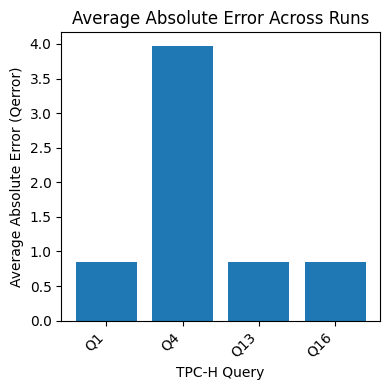

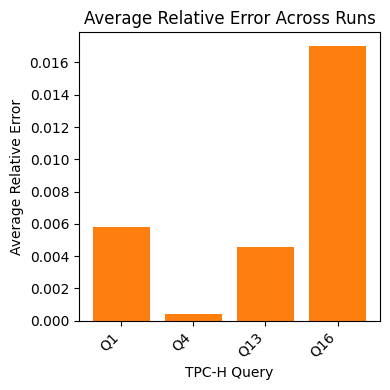

In [17]:
print("opendp eval with TPCH Results Summary:")
os.makedirs("./output/figs", exist_ok=True)

import matplotlib.pyplot as plt

# Use a stable list of labels (convert to strings) and numeric positions for plotting
queries = list(tpch_query_results.keys())
queries_label = [str(q) for q in queries]
print("Queries evaluated:", queries_label)

avg_qerror = [tpch_query_results[q]["mean_qerror_over_runs"] for q in queries]
print("Average Qerror per query:", avg_qerror)
avg_relerror = [tpch_query_results[q]["mean_relerror_over_runs"] for q in queries]
print("Average RelError per query:", avg_relerror)

positions = list(range(len(queries_label)))

# Absolute error bar plot
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(positions, avg_qerror, color='tab:blue')
ax.set_xticks(positions)
ax.set_xticklabels(queries_label, rotation=45, ha='right')
ax.set_xlabel("TPC-H Query")
ax.set_ylabel("Average Absolute Error (Qerror)")
ax.set_title("Average Absolute Error Across Runs")
plt.tight_layout()
plt.show()

# Relative error bar plot
fig2, ax2 = plt.subplots(figsize=(4, 4))
ax2.bar(positions, avg_relerror, color='tab:orange')
ax2.set_xticks(positions)
ax2.set_xticklabels(queries_label, rotation=45, ha='right')
ax2.set_xlabel("TPC-H Query")
ax2.set_ylabel("Average Relative Error")
ax2.set_title("Average Relative Error Across Runs")
plt.tight_layout()
plt.show()